<a href="https://colab.research.google.com/github/Varalakshmi-skab/datasciencelearning/blob/main/SimplelLinearReggresionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [137]:
df = pd.read_csv("/content/drive/MyDrive/Datasets for datascience/height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [138]:
df.isnull().sum() #check null values
df.duplicated() #check for duplicates
df.drop_duplicates() #removing the duplicates
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [139]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


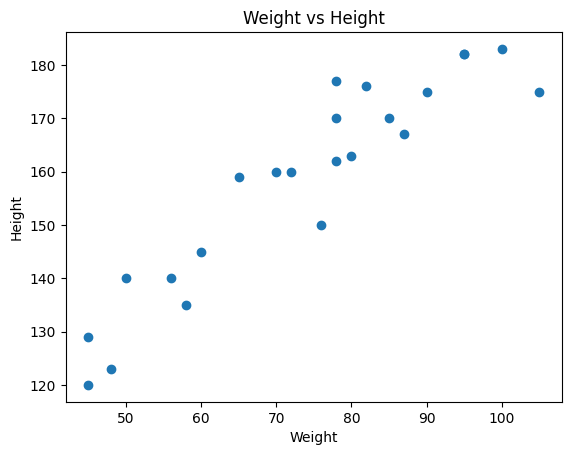

In [140]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Weight vs Height")
plt.show()

In [141]:
X = df[['Weight']]
y = df['Height']

In [142]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [143]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(17, 1)
(6, 1)
(17,)
(6,)


In [144]:
scaler = StandardScaler()

In [145]:
X_train = scaler.fit_transform(X_train)

In [146]:
X_test = scaler.transform(X_test)

In [147]:
model = LinearRegression()

In [148]:
model.fit(X_train, y_train)

LinearRegression()

In [149]:
print("Coefficient :", model.coef_)
print("Intercept :", model.intercept_)

Coefficient : [17.2982057]
Intercept : 156.47058823529412


In [150]:
y_train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
print("Training R² Score :", train_r2)

Training R² Score : 0.9208287444697435


In [151]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R² Score :", r2)

R² Score : 0.7360826717981276


In [152]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE :", mae)

MAE : 9.66512588679501


In [153]:
mse = mean_squared_error(y_test, y_pred)
print("MSE :", mse)

MSE : 114.84069295228699


In [154]:
rmse = np.sqrt(mse)
print("RMSE :", rmse)

RMSE : 10.716374991212605


In [155]:
new_weight = [[72]]
new_weight_scaled = scaler.transform(new_weight)
prediction = model.predict(new_weight_scaled)
print("Predicted Height :", prediction[0])

Predicted Height : 155.9774470462742


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [156]:
import pickle
pickle.dump(model, open('linear_regression_model.pkl', 'wb'))
print("Model Saved Successfully")

Model Saved Successfully


In [157]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))
print("Scaler Saved Successfully")

Scaler Saved Successfully


In [158]:
import pickle
loaded_model = pickle.load(open('linear_regression_model.pkl', 'rb'))
loaded_scaler = pickle.load(open('scaler.pkl', 'rb'))

In [159]:
import pandas as pd
new_weight = [[72]]
new_weight_scaled = loaded_scaler.transform(new_weight)
prediction = loaded_model.predict(new_weight_scaled)
print("Predicted Height :", prediction[0])
# new_weight = pd.DataFrame(
#     {'Weight':[72]}
# )

Predicted Height : 155.9774470462742


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
